# Part 4: Gradient Descent in Code

Here we convert our Part 3 manual calculations into Python. We keep
**matrix form** the whole way through and keep every update step visible,
nothing is hidden behind abstractions.

Model and cost:

$$\hat{y} = X m + b, \qquad J(m,b) = \frac{1}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

Gradients (derived with the chain rule in the Part 3 document):

$$\frac{\partial J}{\partial m} = \frac{2}{n} X^\top (\hat{y} - y), \qquad
  \frac{\partial J}{\partial b} = \frac{2}{n} (\hat{y} - y)$$

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt

from gradient_descent import (X, y, M0, B0, LEARNING_RATE,
                              predict, mse, gradients, gradient_descent)

print("X =\n", X)
print("y =", y)
print("m0 =", M0, " b0 =", B0, " lr =", LEARNING_RATE)

X =
 [[ 1.  3.]
 [ 4. 10.]]
y = [5. 6.]
m0 = [-1.  2.]  b0 = [1. 1.]  lr = 0.01


## 1. Derivative via SciPy

The assignment asks for a SciPy-based function that accepts an equation
and computes its derivative. We use `scipy.differentiate.derivative`,
which numerically differentiates any callable. We apply it to $J$ with
respect to each parameter and check that it matches the analytic matrix
gradient we derived by hand.

In [2]:
from scipy.differentiate import derivative as scipy_derivative

def numerical_gradient(cost_fn, theta):
    """
    Accepts an equation `cost_fn` (a callable of a parameter vector) and
    returns its gradient at `theta`, one SciPy derivative per coordinate.
    """
    grad = np.zeros_like(theta, dtype=float)
    for i in range(len(theta)):
        def along_axis(t, i=i):
            t = np.asarray(t, dtype=float)
            out = np.empty_like(t)
            for j, tj in np.ndenumerate(t):     # scipy passes vectorized input
                th = theta.copy(); th[i] = tj
                out[j] = cost_fn(th)
            return out
        grad[i] = scipy_derivative(along_axis, theta[i]).df
    return grad

def cost_of_params(theta):
    """J as a function of the stacked parameter vector [m1, m2, b1, b2]."""
    m, b = theta[:2], theta[2:]
    return mse(predict(X, m, b), y)

theta0 = np.concatenate([M0, B0])
num_grad = numerical_gradient(cost_of_params, theta0)
ana_m, ana_b, _ = gradients(X, y, M0, B0)

print("SciPy numerical gradient  :", num_grad)
print("Analytic matrix gradient  :", np.concatenate([ana_m, ana_b]))
assert np.allclose(num_grad, np.concatenate([ana_m, ana_b]), atol=1e-6)
print("They match, so our chain rule derivation from Part 3 is confirmed.")

SciPy numerical gradient  : [ 45. 113.   1.  11.]
Analytic matrix gradient  : [ 45. 113.   1.  11.]
They match, so our chain rule derivation from Part 3 is confirmed.


## 2. Four gradient descent updates (one per group member)

Every intermediate quantity gets printed: predictions, error vector, MSE,
both gradients and the updated parameters. These numbers are exactly the
same as our handwritten Part 3 calculations.

In [3]:
m_final, b_final, hist = gradient_descent(X, y, M0, B0,
                                          lr=LEARNING_RATE, iterations=4,
                                          verbose=True)

print("Final m =", m_final)
print("Final b =", b_final)
print("Predictions with final parameters:", predict(X, m_final, b_final))
print("Targets:                          ", y)
print("Final MSE:", mse(predict(X, m_final, b_final), y))

--- Iteration 1 ---
  y_hat        = X @ m + b = [ 6. 17.]
  error e      = y_hat - y = [ 1. 11.]
  MSE          = 61.000000
  dJ/dm        = (2/n) X.T @ e = [ 45. 113.]
  dJ/db        = (2/n) e       = [ 1. 11.]
  m_new        = m - lr*dJ/dm = [-1.45  0.87]
  b_new        = b - lr*dJ/db = [0.99 0.89]

--- Iteration 2 ---
  y_hat        = X @ m + b = [2.15 3.79]
  error e      = y_hat - y = [-2.85 -2.21]
  MSE          = 6.503300
  dJ/dm        = (2/n) X.T @ e = [-11.69 -30.65]
  dJ/db        = (2/n) e       = [-2.85 -2.21]
  m_new        = m - lr*dJ/dm = [-1.3331  1.1765]
  b_new        = b - lr*dJ/db = [1.0185 0.9121]

--- Iteration 3 ---
  y_hat        = X @ m + b = [3.2149 7.3447]
  error e      = y_hat - y = [-1.7851  1.3447]
  MSE          = 2.497400
  dJ/dm        = (2/n) X.T @ e = [3.5937 8.0917]
  dJ/db        = (2/n) e       = [-1.7851  1.3447]
  m_new        = m - lr*dJ/dm = [-1.369037  1.095583]
  b_new        = b - lr*dJ/db = [1.036351 0.898653]

--- Iteration 4 ---
  y_ha

## 3. Plots

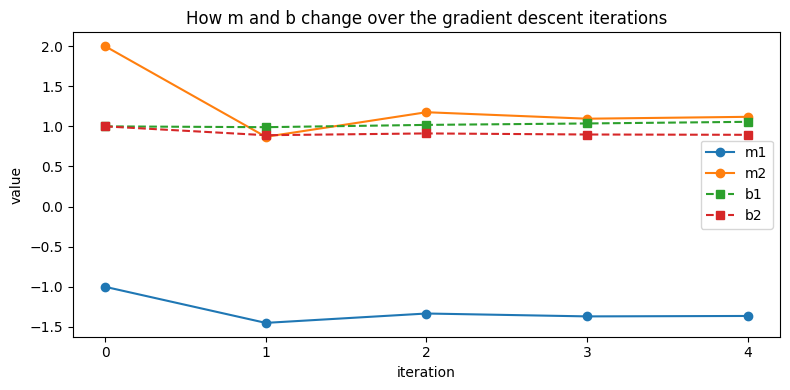

In [4]:
its = np.arange(len(hist["mse"]))
ms = np.array(hist["m"]); bs = np.array(hist["b"])

plt.figure(figsize=(8, 4))
plt.plot(its, ms[:, 0], marker="o", label="m1")
plt.plot(its, ms[:, 1], marker="o", label="m2")
plt.plot(its, bs[:, 0], marker="s", ls="--", label="b1")
plt.plot(its, bs[:, 1], marker="s", ls="--", label="b2")
plt.title("How m and b change over the gradient descent iterations")
plt.xlabel("iteration"); plt.ylabel("value"); plt.xticks(its); plt.legend()
plt.tight_layout(); plt.savefig("../docs/img_params_over_iters.png", dpi=120)
plt.show()

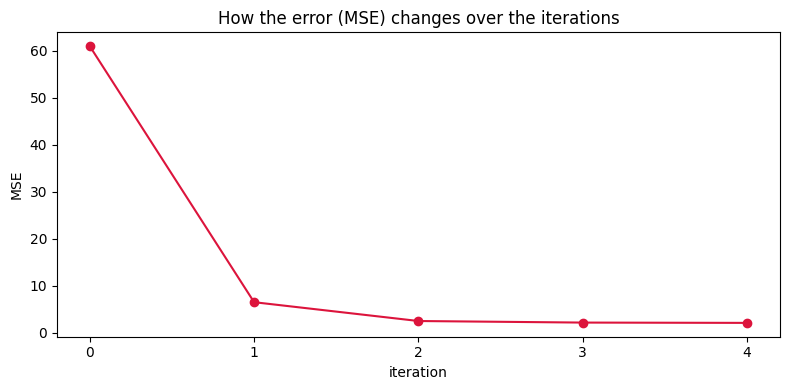

iteration 0: MSE = 61.000000
iteration 1: MSE = 6.503300
iteration 2: MSE = 2.497400
iteration 3: MSE = 2.164498
iteration 4: MSE = 2.099581


In [5]:
plt.figure(figsize=(8, 4))
plt.plot(its, hist["mse"], marker="o", color="crimson")
plt.title("How the error (MSE) changes over the iterations")
plt.xlabel("iteration"); plt.ylabel("MSE"); plt.xticks(its)
plt.tight_layout(); plt.savefig("../docs/img_error_over_iters.png", dpi=120)
plt.show()

for i, e in enumerate(hist["mse"]):
    print(f"iteration {i}: MSE = {e:.6f}")

### Trend we observe
The MSE drops steeply after the first update (61.0 down to about 6.5) and
keeps decreasing every iteration after that. m and b move opposite to
their gradients: the large positive gradient on $m_2$ pulls it down hard
first, then the parameters take smaller, stabilizing steps as the error
surface flattens out. So yes, m and b are moving in a direction that
reduces the error, which is exactly what gradient descent should do with
a reasonable learning rate.